# 📊 RETO 6 - OPEN DATA: Descarga de Open Data INE

**Proyecto:** Observatorio de Comercio Minorista - España  
**Fuente:** Instituto Nacional de Estadística (INE) - API JSON  
**Autor:** Ana BM  
**Fecha:** Marzo 2026  

---

## 🎯 Objetivos de este Notebook:

1. ✅ Descargar IPC Nacional mensual (2021-2023)
2. ✅ Descargar IPC por Grupos ECOICOP (categorías)
3. ✅ Descargar IPC por Comunidades Autónomas
4. ✅ Preparar datos para integración con dataset principal
5. ✅ Validar calidad de Open Data descargado

---

## 📚 DOCUMENTACIÓN APIs INE:
- **API JSON INE:** https://www.ine.es/dyngs/DataLab/manual.html?cid=45
- **IPC - Operación:** https://www.ine.es/dyngs/INEbase/es/operacion.htm?c=Estadistica_C&cid=1254736176802

---

## 📦 CELDA 1: Importar Librerías

In [4]:
# Librerías principales
import pandas as pd
import numpy as np
import requests
import json
import warnings
from datetime import datetime
import time

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Librerías importadas correctamente")
print(f"📅 Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías importadas correctamente
📅 Fecha de ejecución: 2026-03-18 08:48:37


## 🔌 CELDA 2: Montar Google Drive

In [5]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("\n✅ Google Drive montado correctamente")

Mounted at /content/drive

✅ Google Drive montado correctamente


## 🗂️ CELDA 3: Definir Rutas y Configuración

In [6]:
# Rutas en Google Drive
BASE_PATH = '/content/drive/MyDrive/Reto-6-Open-Data/data/raw/'

# Configuración temporal del proyecto
FECHA_INICIO = '2021-01-01'
FECHA_FIN = '2023-03-31'  # Marzo 2023 (cubrimos todo el período del dataset)

print("="*80)
print("📋 CONFIGURACIÓN DEL PROYECTO")
print("="*80)
print(f"\n📅 Período de datos a descargar:")
print(f"   • Fecha inicio: {FECHA_INICIO}")
print(f"   • Fecha fin: {FECHA_FIN}")
print(f"   • Meses totales: 27 meses")
print(f"\n💾 Ruta de guardado: {BASE_PATH}")
print("\n✅ Configuración completada")

📋 CONFIGURACIÓN DEL PROYECTO

📅 Período de datos a descargar:
   • Fecha inicio: 2021-01-01
   • Fecha fin: 2023-03-31
   • Meses totales: 27 meses

💾 Ruta de guardado: /content/drive/MyDrive/Reto-6-Open-Data/data/raw/

✅ Configuración completada


In [7]:
# CELDA DE PRUEBA - DIAGNÓSTICO API INE
import requests
import json

print("🔍 DIAGNÓSTICO API INE")
print("="*80)

# Probar URL simplificada (sin filtro de fecha)
url_test = "https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/IPC251852?nult=27"

print(f"\n🔗 Probando URL: {url_test}")

try:
    response = requests.get(url_test, timeout=10)
    print(f"   • Status code: {response.status_code}")
    print(f"   • Tamaño respuesta: {len(response.text)} caracteres")

    if response.status_code == 200:
        data = response.json()
        print(f"   • Tipo de respuesta: {type(data)}")

        # ✅ CORRECCIÓN 1: Verificar si es dict o list
        if isinstance(data, dict):
            print(f"   • Claves principales: {list(data.keys())}")

            # ✅ CORRECCIÓN 2: Acceder correctamente a 'Data'
            if 'Data' in data:
                print(f"   • Registros en 'Data': {len(data['Data'])}")
                print("\n📊 MUESTRA DE DATOS (primeros 3 registros):")
                print(json.dumps(data['Data'][:3], indent=2, ensure_ascii=False))
            else:
                print("   ⚠️ No se encuentra la clave 'Data'")

        elif isinstance(data, list):
            print(f"   • Es una lista con {len(data)} elementos")
            print(f"   • Estructura del primer elemento: {list(data[0].keys()) if data else 'vacío'}")

        # Mostrar muestra de la respuesta completa
        print("\n📄 MUESTRA DE RESPUESTA RAW (primeros 500 caracteres):")
        print(response.text[:500])

    else:
        print(f"   ❌ Error HTTP: {response.status_code}")

except Exception as e:
    print(f"   ❌ Error: {e}")
    import traceback
    traceback.print_exc()

🔍 DIAGNÓSTICO API INE

🔗 Probando URL: https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/IPC251852?nult=27
   • Status code: 200
   • Tamaño respuesta: 3260 caracteres
   • Tipo de respuesta: <class 'dict'>
   • Claves principales: ['COD', 'Nombre', 'FK_Unidad', 'FK_Escala', 'Notas', 'Data']
   • Registros en 'Data': 27

📊 MUESTRA DE DATOS (primeros 3 registros):
[
  {
    "Fecha": 1696111200000,
    "FK_TipoDato": 1,
    "FK_Periodo": 10,
    "Anyo": 2023,
    "Valor": 113.676,
    "Secreto": false
  },
  {
    "Fecha": 1698793200000,
    "FK_TipoDato": 1,
    "FK_Periodo": 11,
    "Anyo": 2023,
    "Valor": 113.28,
    "Secreto": false
  },
  {
    "Fecha": 1701385200000,
    "FK_TipoDato": 1,
    "FK_Periodo": 12,
    "Anyo": 2023,
    "Valor": 113.308,
    "Secreto": false
  }
]

📄 MUESTRA DE RESPUESTA RAW (primeros 500 caracteres):
{"COD":"IPC251852", "Nombre":"Total Nacional. Índice general. Índice. ", "FK_Unidad":133, "FK_Escala":1, "Notas":[{"texto" : "https://www.ine.es/dyng

In [8]:
# VER ESTRUCTURA COMPLETA DEL JSON
import requests
import json

url_test = "https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/IPC251852?nult=27"

response = requests.get(url_test)
data = response.json()

print("📊 ESTRUCTURA DEL JSON:")
print("="*80)
print(f"Tipo: {type(data)}")
print(f"\nClaves principales: {list(data.keys())}")

# Mostrar estructura completa (formato bonito)
print("\n📄 JSON COMPLETO:")
print(json.dumps(data, indent=2, ensure_ascii=False)[:1000])  # Primeros 1000 caracteres

📊 ESTRUCTURA DEL JSON:
Tipo: <class 'dict'>

Claves principales: ['COD', 'Nombre', 'FK_Unidad', 'FK_Escala', 'Notas', 'Data']

📄 JSON COMPLETO:
{
  "COD": "IPC251852",
  "Nombre": "Total Nacional. Índice general. Índice. ",
  "FK_Unidad": 133,
  "FK_Escala": 1,
  "Notas": [
    {
      "texto": "https://www.ine.es/dyngs/INEbase/es/operacion.htm?c=Estadistica_C&cid=1254736176802&menu=ultiDatos&idp=1254735976607#~#https://www.ine.es/consul/serie.do?s=IPC206446&nult=100&TB_iframe=true&position=center&width=700&height=500&L=0&nocab=1 ",
      "Fk_TipoNota": 6,
      "textoTipo": null
    }
  ],
  "Data": [
    {
      "Fecha": 1696111200000,
      "FK_TipoDato": 1,
      "FK_Periodo": 10,
      "Anyo": 2023,
      "Valor": 113.676,
      "Secreto": false
    },
    {
      "Fecha": 1698793200000,
      "FK_TipoDato": 1,
      "FK_Periodo": 11,
      "Anyo": 2023,
      "Valor": 113.28,
      "Secreto": false
    },
    {
      "Fecha": 1701385200000,
      "FK_TipoDato": 1,
      "FK_Perio

## 📊 CELDA 4: Descargar IPC Nacional Mensual (Serie General)

In [20]:
print("="*80)
print("📊 DESCARGANDO IPC NACIONAL MENSUAL")
print("="*80)

# Usar tabla 50902: Índices nacionales: general y de grupos ECOICOP
# Filtraremos solo el índice general
url_ipc_nacional = "https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/50902?nult=60"

print("\n🔗 URL API INE:")
print(url_ipc_nacional)

try:
    response = requests.get(url_ipc_nacional, timeout=15)
    response.raise_for_status()

    data_json = response.json()

    print(f"\n✅ Respuesta recibida: {len(data_json)} series")

    # Buscar la serie del índice general
    df_ipc_nacional = None

    for serie in data_json:
        nombre_serie = serie.get('Nombre', '')

        # Buscar "Total Nacional" + "Índice general" + "Índice."
        if ('Total Nacional' in nombre_serie and
            'Índice general' in nombre_serie and
            'Índice.' in nombre_serie and
            'Data' in serie):

            # Convertir a DataFrame
            df_temp = pd.DataFrame(serie['Data'])

            if len(df_temp) > 0:
                df_temp['Fecha'] = pd.to_datetime(df_temp['Fecha'], unit='ms')
                df_temp['year'] = df_temp['Fecha'].dt.year
                df_temp['month'] = df_temp['Fecha'].dt.month
                df_temp = df_temp.rename(columns={'Valor': 'IPC_Nacional'})

                df_ipc_nacional = df_temp
                print(f"\n✅ Serie encontrada: {nombre_serie[:80]}")
                break

    if df_ipc_nacional is not None:
        print(f"\n📊 DATOS DESCARGADOS (antes de filtrar):")
        print(f"   • Total registros: {len(df_ipc_nacional)}")
        print(f"   • Período completo: {df_ipc_nacional['Fecha'].min().strftime('%Y-%m')} a {df_ipc_nacional['Fecha'].max().strftime('%Y-%m')}")
        print(f"   • Años únicos: {sorted(df_ipc_nacional['year'].unique())}")

        # Filtrar solo período 2021-2023
        df_ipc_nacional = df_ipc_nacional[
            (df_ipc_nacional['year'] >= 2021) &
            (df_ipc_nacional['year'] <= 2023)
        ].copy()

        # Seleccionar columnas relevantes
        df_ipc_nacional = df_ipc_nacional[['Fecha', 'year', 'month', 'IPC_Nacional']].sort_values('Fecha')

        print(f"\n✅ IPC Nacional descargado correctamente")
        print(f"   • Registros obtenidos (después de filtrar): {len(df_ipc_nacional)}")
        print(f"   • Período: {df_ipc_nacional['Fecha'].min().strftime('%Y-%m-%d')} a {df_ipc_nacional['Fecha'].max().strftime('%Y-%m-%d')}")

        # Mostrar distribución por año
        print(f"\n📊 DISTRIBUCIÓN POR AÑO:")
        print(df_ipc_nacional.groupby('year').size())

        # Guardar CSV
        ruta_guardado = BASE_PATH + 'ine_ipc_nacional.csv'
        df_ipc_nacional.to_csv(ruta_guardado, index=False)
        print(f"\n💾 Guardado en: {ruta_guardado}")

        # Mostrar primeras y últimas filas
        print("\n📊 PRIMERAS FILAS:")
        display(df_ipc_nacional.head(5))

        print("\n📊 ÚLTIMAS FILAS:")
        display(df_ipc_nacional.tail(5))

    else:
        print("\n❌ No se encontró la serie de IPC General Nacional")
        print("\n📋 Series disponibles (primeras 10):")
        for i, serie in enumerate(data_json[:10]):
            print(f"   {i+1}. {serie.get('Nombre', '')[:100]}")

except Exception as e:
    print(f"\n❌ ERROR al descargar IPC Nacional: {e}")
    import traceback
    traceback.print_exc()

📊 DESCARGANDO IPC NACIONAL MENSUAL

🔗 URL API INE:
https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/50902?nult=60

✅ Respuesta recibida: 52 series

✅ Serie encontrada: Total Nacional. Índice general. Índice. 

📊 DATOS DESCARGADOS (antes de filtrar):
   • Total registros: 60
   • Período completo: 2020-12 a 2025-11
   • Años únicos: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

✅ IPC Nacional descargado correctamente
   • Registros obtenidos (después de filtrar): 36
   • Período: 2021-01-31 a 2023-12-31

📊 DISTRIBUCIÓN POR AÑO:
year
2021    12
2022    12
2023    12
dtype: int64

💾 Guardado en: /content/drive/MyDrive/Reto-6-Open-Data/data/raw/ine_ipc_nacional.csv

📊 PRIMERAS FILAS:


,Fecha,year,month,IPC_Nacional
58,2021-01-31 23:00:00,2021,1,97.008
57,2021-02-28 23:00:00,2021,2,97.949
56,2021-03-31 22:00:00,2021,3,99.105
55,2021-04-30 22:00:00,2021,4,99.572
54,2021-05-31 22:00:00,2021,5,100.046



📊 ÚLTIMAS FILAS:


,Fecha,year,month,IPC_Nacional
27,2023-08-31 22:00:00,2023,8,113.348
26,2023-09-30 22:00:00,2023,9,113.676
25,2023-10-31 23:00:00,2023,10,113.280
24,2023-11-30 23:00:00,2023,11,113.308
23,2023-12-31 23:00:00,2023,12,113.404


## 🏷️ CELDA 5: Descargar IPC por Grupos ECOICOP (Categorías)

In [23]:
print("="*80)
print("🏷️ DESCARGANDO IPC POR GRUPOS ECOICOP (CATEGORÍAS)")
print("="*80)

# Cargar mapeo de categorías
ruta_mapeo_cat = '/content/drive/MyDrive/Reto-6-Open-Data/data/mapping/categories_ecoicop_mapping.csv'
df_mapeo_cat = pd.read_csv(ruta_mapeo_cat)

print("\n📋 CATEGORÍAS ECOICOP A DESCARGAR:")
categorias_unicas = df_mapeo_cat[['codigo_ecoicop', 'grupo_ecoicop']].drop_duplicates()
print(categorias_unicas.to_string(index=False))

# Usar tabla 50902: Índices nacionales: general y de grupos ECOICOP
# Esta tabla tiene todos los grupos con cobertura completa 2021-2023
url_tabla = "https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/50902?nult=60"

print("\n🔗 URL API INE:")
print(url_tabla)

try:
    response = requests.get(url_tabla, timeout=15)
    response.raise_for_status()

    data_json = response.json()

    print(f"\n✅ Respuesta recibida: {len(data_json)} series")

    # Mapeo de nombres de grupos ECOICOP a códigos
    mapeo_nombres = {
        'Alimentos y bebidas no alcohólicas': '01',
        'Vestido y calzado': '03',
        'Comunicaciones': '08',
        'Ocio y cultura': '09',
        'Otros bienes y servicios': '12'
    }

    # Lista para almacenar datos
    df_list = []

    # Procesar cada serie
    print("\n🔄 Procesando series...")

    for serie in data_json:
        try:
            nombre_serie = serie.get('Nombre', '')

            # Buscar si el nombre contiene alguno de nuestros grupos
            codigo_encontrado = None
            nombre_encontrado = None

            for nombre_grupo, codigo in mapeo_nombres.items():
                # Debe contener el nombre del grupo + "Índice." (no variación)
                if (nombre_grupo in nombre_serie and
                    'Índice.' in nombre_serie and
                    'Total Nacional' in nombre_serie):
                    codigo_encontrado = codigo
                    nombre_encontrado = nombre_grupo
                    break

            # Si encontramos un código que necesitamos
            if codigo_encontrado and 'Data' in serie:
                df_temp = pd.DataFrame(serie['Data'])

                if len(df_temp) > 0:
                    df_temp['Fecha'] = pd.to_datetime(df_temp['Fecha'], unit='ms')
                    df_temp['codigo_ecoicop'] = int(codigo_encontrado)
                    df_temp = df_temp.rename(columns={'Valor': 'IPC_Categoria'})

                    # Filtrar 2021-2023
                    df_temp = df_temp[
                        (df_temp['Fecha'].dt.year >= 2021) &
                        (df_temp['Fecha'].dt.year <= 2023)
                    ].copy()

                    if len(df_temp) > 0:
                        df_temp = df_temp[['Fecha', 'codigo_ecoicop', 'IPC_Categoria']]
                        df_list.append(df_temp)

                        print(f"   ✅ Código {codigo_encontrado} - {nombre_encontrado}: {len(df_temp)} registros")

        except Exception as e:
            continue

    # Combinar todos los DataFrames
    if df_list:
        df_ipc_categorias = pd.concat(df_list, ignore_index=True)

        # Añadir nombres de grupos
        df_ipc_categorias = df_ipc_categorias.merge(
            categorias_unicas,
            on='codigo_ecoicop',
            how='left'
        )

        print(f"\n✅ IPC por Categorías descargado correctamente")
        print(f"   • Total registros: {len(df_ipc_categorias)}")
        print(f"   • Categorías únicas: {df_ipc_categorias['codigo_ecoicop'].nunique()}")

        # Mostrar distribución por año
        df_ipc_categorias['year'] = df_ipc_categorias['Fecha'].dt.year
        print(f"\n📊 DISTRIBUCIÓN POR AÑO:")
        print(df_ipc_categorias.groupby('year').size())

        # Verificar cobertura por categoría
        print(f"\n📊 REGISTROS POR CATEGORÍA Y AÑO:")
        pivot = df_ipc_categorias.groupby(['codigo_ecoicop', 'year']).size().unstack(fill_value=0)
        print(pivot)

        # Guardar CSV
        ruta_guardado = BASE_PATH + 'ine_ipc_categorias.csv'
        df_ipc_categorias.to_csv(ruta_guardado, index=False)
        print(f"\n💾 Guardado en: {ruta_guardado}")

        # Mostrar muestra
        print("\n📊 MUESTRA DE DATOS:")
        display(df_ipc_categorias.head(15))

    else:
        print("\n❌ No se pudo extraer ninguna categoría de la tabla")
        print("\n📋 Mostrando series con grupos ECOICOP:")
        for i, serie in enumerate(data_json[:30]):
            nombre = serie.get('Nombre', '')
            if any(grupo in nombre for grupo in mapeo_nombres.keys()):
                print(f"   {i+1}. {nombre[:120]}")

except Exception as e:
    print(f"\n❌ ERROR al descargar IPC por Categorías: {e}")
    import traceback
    traceback.print_exc()

🏷️ DESCARGANDO IPC POR GRUPOS ECOICOP (CATEGORÍAS)

📋 CATEGORÍAS ECOICOP A DESCARGAR:
 codigo_ecoicop                      grupo_ecoicop
              1 Alimentos y bebidas no alcohólicas
              3                  Vestido y calzado
              8                     Comunicaciones
             12           Otros bienes y servicios
              9                     Ocio y cultura

🔗 URL API INE:
https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/50902?nult=60

✅ Respuesta recibida: 52 series

🔄 Procesando series...
   ✅ Código 01 - Alimentos y bebidas no alcohólicas: 36 registros
   ✅ Código 03 - Vestido y calzado: 36 registros
   ✅ Código 08 - Comunicaciones: 36 registros
   ✅ Código 09 - Ocio y cultura: 36 registros
   ✅ Código 12 - Otros bienes y servicios: 36 registros

✅ IPC por Categorías descargado correctamente
   • Total registros: 180
   • Categorías únicas: 5

📊 DISTRIBUCIÓN POR AÑO:
year
2021    60
2022    60
2023    60
dtype: int64

📊 REGISTROS POR CATEGORÍA Y AÑ

,Fecha,codigo_ecoicop,IPC_Categoria,grupo_ecoicop,year
0,2023-12-31 23:00:00,1,128.395,Alimentos y bebidas no alcohólicas,2023
1,2023-11-30 23:00:00,1,127.728,Alimentos y bebidas no alcohólicas,2023
2,2023-10-31 23:00:00,1,127.761,Alimentos y bebidas no alcohólicas,2023
3,2023-09-30 22:00:00,1,127.630,Alimentos y bebidas no alcohólicas,2023
4,2023-08-31 22:00:00,1,126.029,Alimentos y bebidas no alcohólicas,2023
5,2023-07-31 22:00:00,1,125.420,Alimentos y bebidas no alcohólicas,2023
6,2023-06-30 22:00:00,1,125.193,Alimentos y bebidas no alcohólicas,2023
7,2023-05-31 22:00:00,1,124.245,Alimentos y bebidas no alcohólicas,2023
8,2023-04-30 22:00:00,1,123.935,Alimentos y bebidas no alcohólicas,2023
9,2023-03-31 22:00:00,1,123.474,Alimentos y bebidas no alcohólicas,2023


## 🗺️ CELDA 6: Descargar IPC por Comunidades Autónomas

In [22]:
print("="*80)
print("🗺️ DESCARGANDO IPC POR COMUNIDADES AUTÓNOMAS")
print("="*80)

# Cargar mapeo geográfico
ruta_mapeo_geo = '/content/drive/MyDrive/Reto-6-Open-Data/data/mapping/istanbul_spain_mapping.csv'
df_mapeo_geo = pd.read_csv(ruta_mapeo_geo)

print("\n📋 COMUNIDADES AUTÓNOMAS A DESCARGAR:")
ccaa_unicas = df_mapeo_geo[['ccaa', 'codigo_ccaa']].drop_duplicates().sort_values('codigo_ccaa')
print(ccaa_unicas.to_string(index=False))

# Usar tabla 50913: Índices por CCAA - general y grupos ECOICOP
# Aumentamos nult=60 para cubrir 2021-2023 completo
url_tabla = "https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/50913?nult=60"

print("\n🔗 URL API INE:")
print(url_tabla)

try:
    response = requests.get(url_tabla, timeout=15)
    response.raise_for_status()

    data_json = response.json()

    print(f"\n✅ Respuesta recibida: {len(data_json)} series")

    # Mapeo de nombres CCAA a códigos
    mapeo_ccaa = {
        'Andalucía': '01',
        'Aragón': '02',
        'Balears, Illes': '04',
        'Canarias': '05',
        'Cataluña': '09',
        'Comunitat Valenciana': '10',
        'Madrid, Comunidad de': '13',
        'País Vasco': '16'
    }

    # Lista para almacenar datos
    df_list = []

    # Procesar cada serie
    print("\n🔄 Procesando series...")

    for serie in data_json:
        try:
            nombre_serie = serie.get('Nombre', '')

            # Buscar CCAA en el nombre + que sea índice general
            codigo_encontrado = None
            nombre_ccaa_encontrado = None

            for nombre_ccaa, codigo in mapeo_ccaa.items():
                # Buscar series que contengan el nombre de la CCAA y "Índice general" y "Índice."
                if (nombre_ccaa in nombre_serie and
                    'Índice general' in nombre_serie and
                    'Índice.' in nombre_serie):
                    codigo_encontrado = codigo
                    nombre_ccaa_encontrado = nombre_ccaa
                    break

            # Si encontramos una CCAA que necesitamos
            if codigo_encontrado and 'Data' in serie:
                df_temp = pd.DataFrame(serie['Data'])

                if len(df_temp) > 0:
                    df_temp['Fecha'] = pd.to_datetime(df_temp['Fecha'], unit='ms')
                    df_temp['codigo_ccaa'] = codigo_encontrado
                    df_temp = df_temp.rename(columns={'Valor': 'IPC_CCAA'})

                    # Filtrar 2021-2023
                    df_temp = df_temp[
                        (df_temp['Fecha'].dt.year >= 2021) &
                        (df_temp['Fecha'].dt.year <= 2023)
                    ].copy()

                    if len(df_temp) > 0:
                        df_temp = df_temp[['Fecha', 'codigo_ccaa', 'IPC_CCAA']]
                        df_list.append(df_temp)

                        print(f"   ✅ {nombre_ccaa_encontrado}: {len(df_temp)} registros")

        except Exception as e:
            continue

    # Combinar todos los DataFrames
    if df_list:
        df_ipc_ccaa = pd.concat(df_list, ignore_index=True)

        # Añadir nombres de CCAA
        ccaa_unicas['codigo_ccaa'] = ccaa_unicas['codigo_ccaa'].astype(str).str.zfill(2)
        df_ipc_ccaa = df_ipc_ccaa.merge(
            ccaa_unicas,
            on='codigo_ccaa',
            how='left'
        )

        print(f"\n✅ IPC por CCAA descargado correctamente")
        print(f"   • Total registros: {len(df_ipc_ccaa)}")
        print(f"   • CCAA únicas: {df_ipc_ccaa['codigo_ccaa'].nunique()}")

        # Mostrar distribución por año
        df_ipc_ccaa['year'] = df_ipc_ccaa['Fecha'].dt.year
        print(f"\n📊 DISTRIBUCIÓN POR AÑO:")
        print(df_ipc_ccaa.groupby('year').size())

        # Verificar cobertura por CCAA
        print(f"\n📊 REGISTROS POR CCAA Y AÑO:")
        pivot = df_ipc_ccaa.groupby(['codigo_ccaa', 'year']).size().unstack(fill_value=0)
        print(pivot)

        # Guardar CSV
        ruta_guardado = BASE_PATH + 'ine_ipc_ccaa.csv'
        df_ipc_ccaa.to_csv(ruta_guardado, index=False)
        print(f"\n💾 Guardado en: {ruta_guardado}")

        # Mostrar muestra
        print("\n📊 MUESTRA DE DATOS:")
        display(df_ipc_ccaa.head(15))

    else:
        print("\n❌ No se pudo extraer ninguna CCAA de la tabla")

except Exception as e:
    print(f"\n❌ ERROR al descargar IPC por CCAA: {e}")
    import traceback
    traceback.print_exc()

🗺️ DESCARGANDO IPC POR COMUNIDADES AUTÓNOMAS

📋 COMUNIDADES AUTÓNOMAS A DESCARGAR:
                ccaa  codigo_ccaa
           Andalucía            1
              Aragón            2
       Illes Balears            4
            Canarias            5
            Cataluña            9
Comunitat Valenciana           10
              Madrid           13
          País Vasco           16

🔗 URL API INE:
https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/50913?nult=60

✅ Respuesta recibida: 1040 series

🔄 Procesando series...
   ✅ Andalucía: 36 registros
   ✅ Aragón: 36 registros
   ✅ Balears, Illes: 36 registros
   ✅ Canarias: 36 registros
   ✅ Cataluña: 36 registros
   ✅ Comunitat Valenciana: 36 registros
   ✅ Madrid, Comunidad de: 36 registros
   ✅ País Vasco: 36 registros

✅ IPC por CCAA descargado correctamente
   • Total registros: 288
   • CCAA únicas: 8

📊 DISTRIBUCIÓN POR AÑO:
year
2021    96
2022    96
2023    96
dtype: int64

📊 REGISTROS POR CCAA Y AÑO:
year         2021  2022

,Fecha,codigo_ccaa,IPC_CCAA,ccaa,year
0,2023-12-31 23:00:00,01,114.238,Andalucía,2023
1,2023-11-30 23:00:00,01,114.121,Andalucía,2023
2,2023-10-31 23:00:00,01,114.188,Andalucía,2023
3,2023-09-30 22:00:00,01,114.716,Andalucía,2023
4,2023-08-31 22:00:00,01,114.025,Andalucía,2023
5,2023-07-31 22:00:00,01,113.700,Andalucía,2023
6,2023-06-30 22:00:00,01,113.013,Andalucía,2023
7,2023-05-31 22:00:00,01,113.045,Andalucía,2023
8,2023-04-30 22:00:00,01,112.551,Andalucía,2023
9,2023-03-31 22:00:00,01,112.587,Andalucía,2023


In [12]:
# DIAGNÓSTICO: Buscar cómo aparece Baleares
print("🔍 BUSCANDO NOMBRE DE BALEARES EN INE")
print("="*80)

url_tabla = "https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/50913?nult=40"
response = requests.get(url_tabla, timeout=15)
data_json = response.json()

# Buscar series que contengan "Bale" o "Ille"
print("\n📋 Series que contienen 'Bale' o 'Ille':")
count = 0
for serie in data_json:
    nombre = serie.get('Nombre', '')
    if ('Bale' in nombre or 'Ille' in nombre) and 'Índice general' in nombre:
        print(f"   {count+1}. {nombre}")
        count += 1
        if count >= 5:
            break

if count == 0:
    print("   ❌ No se encontró ninguna serie con 'Bale' o 'Ille'")
    print("\n📋 Mostrando todas las CCAA con 'Índice general':")
    ccaa_encontradas = set()
    for serie in data_json:
        nombre = serie.get('Nombre', '')
        if 'Índice general' in nombre and 'Índice.' in nombre:
            # Extraer nombre CCAA (viene después del primer punto)
            partes = nombre.split('. ')
            if len(partes) > 1:
                ccaa = partes[0]
                ccaa_encontradas.add(ccaa)

    for ccaa in sorted(ccaa_encontradas):
        print(f"   • {ccaa}")

🔍 BUSCANDO NOMBRE DE BALEARES EN INE

📋 Series que contienen 'Bale' o 'Ille':
   1. Balears, Illes. Índice general. Índice. 
   2. Balears, Illes. Índice general. Variación mensual. 
   3. Balears, Illes. Índice general. Variación anual. 
   4. Balears, Illes. Índice general. Variación en lo que va de año. 


## ✅ CELDA 7: Validación de Datos Descargados

In [13]:
print("="*80)
print("✅ VALIDACIÓN DE OPEN DATA DESCARGADO")
print("="*80)

print("\n1️⃣ IPC NACIONAL:")
print(f"   • Registros: {len(df_ipc_nacional)}")
print(f"   • Rango fechas: {df_ipc_nacional['Fecha'].min()} a {df_ipc_nacional['Fecha'].max()}")
print(f"   • Valores nulos: {df_ipc_nacional['IPC_Nacional'].isnull().sum()}")
print(f"   • IPC min: {df_ipc_nacional['IPC_Nacional'].min():.2f}")
print(f"   • IPC max: {df_ipc_nacional['IPC_Nacional'].max():.2f}")

print("\n2️⃣ IPC POR CATEGORÍAS:")
print(f"   • Registros: {len(df_ipc_categorias)}")
print(f"   • Categorías únicas: {df_ipc_categorias['codigo_ecoicop'].nunique()}")
print(f"   • Valores nulos: {df_ipc_categorias['IPC_Categoria'].isnull().sum()}")
print("\n   Registros por categoría:")
print(df_ipc_categorias.groupby('grupo_ecoicop').size())

print("\n3️⃣ IPC POR CCAA:")
print(f"   • Registros: {len(df_ipc_ccaa)}")
print(f"   • CCAA únicas: {df_ipc_ccaa['codigo_ccaa'].nunique()}")
print(f"   • Valores nulos: {df_ipc_ccaa['IPC_CCAA'].isnull().sum()}")
print("\n   Registros por CCAA:")
print(df_ipc_ccaa.groupby('ccaa').size())

print("\n" + "="*80)
print("🎉 VALIDACIÓN COMPLETADA")
print("="*80)

✅ VALIDACIÓN DE OPEN DATA DESCARGADO

1️⃣ IPC NACIONAL:
   • Registros: 17
   • Rango fechas: 2022-08-31 22:00:00 a 2023-12-31 23:00:00
   • Valores nulos: 0
   • IPC min: 109.50
   • IPC max: 113.68

2️⃣ IPC POR CATEGORÍAS:
   • Registros: 55
   • Categorías únicas: 5
   • Valores nulos: 0

   Registros por categoría:
grupo_ecoicop
Alimentos y bebidas no alcohólicas    11
Comunicaciones                        11
Ocio y cultura                        11
Otros bienes y servicios              11
Vestido y calzado                     11
dtype: int64

3️⃣ IPC POR CCAA:
   • Registros: 136
   • CCAA únicas: 8
   • Valores nulos: 0

   Registros por CCAA:
ccaa
Andalucía               17
Aragón                  17
Canarias                17
Cataluña                17
Comunitat Valenciana    17
Illes Balears           17
Madrid                  17
País Vasco              17
dtype: int64

🎉 VALIDACIÓN COMPLETADA


## 📊 CELDA 8: Visualización Rápida de Open Data

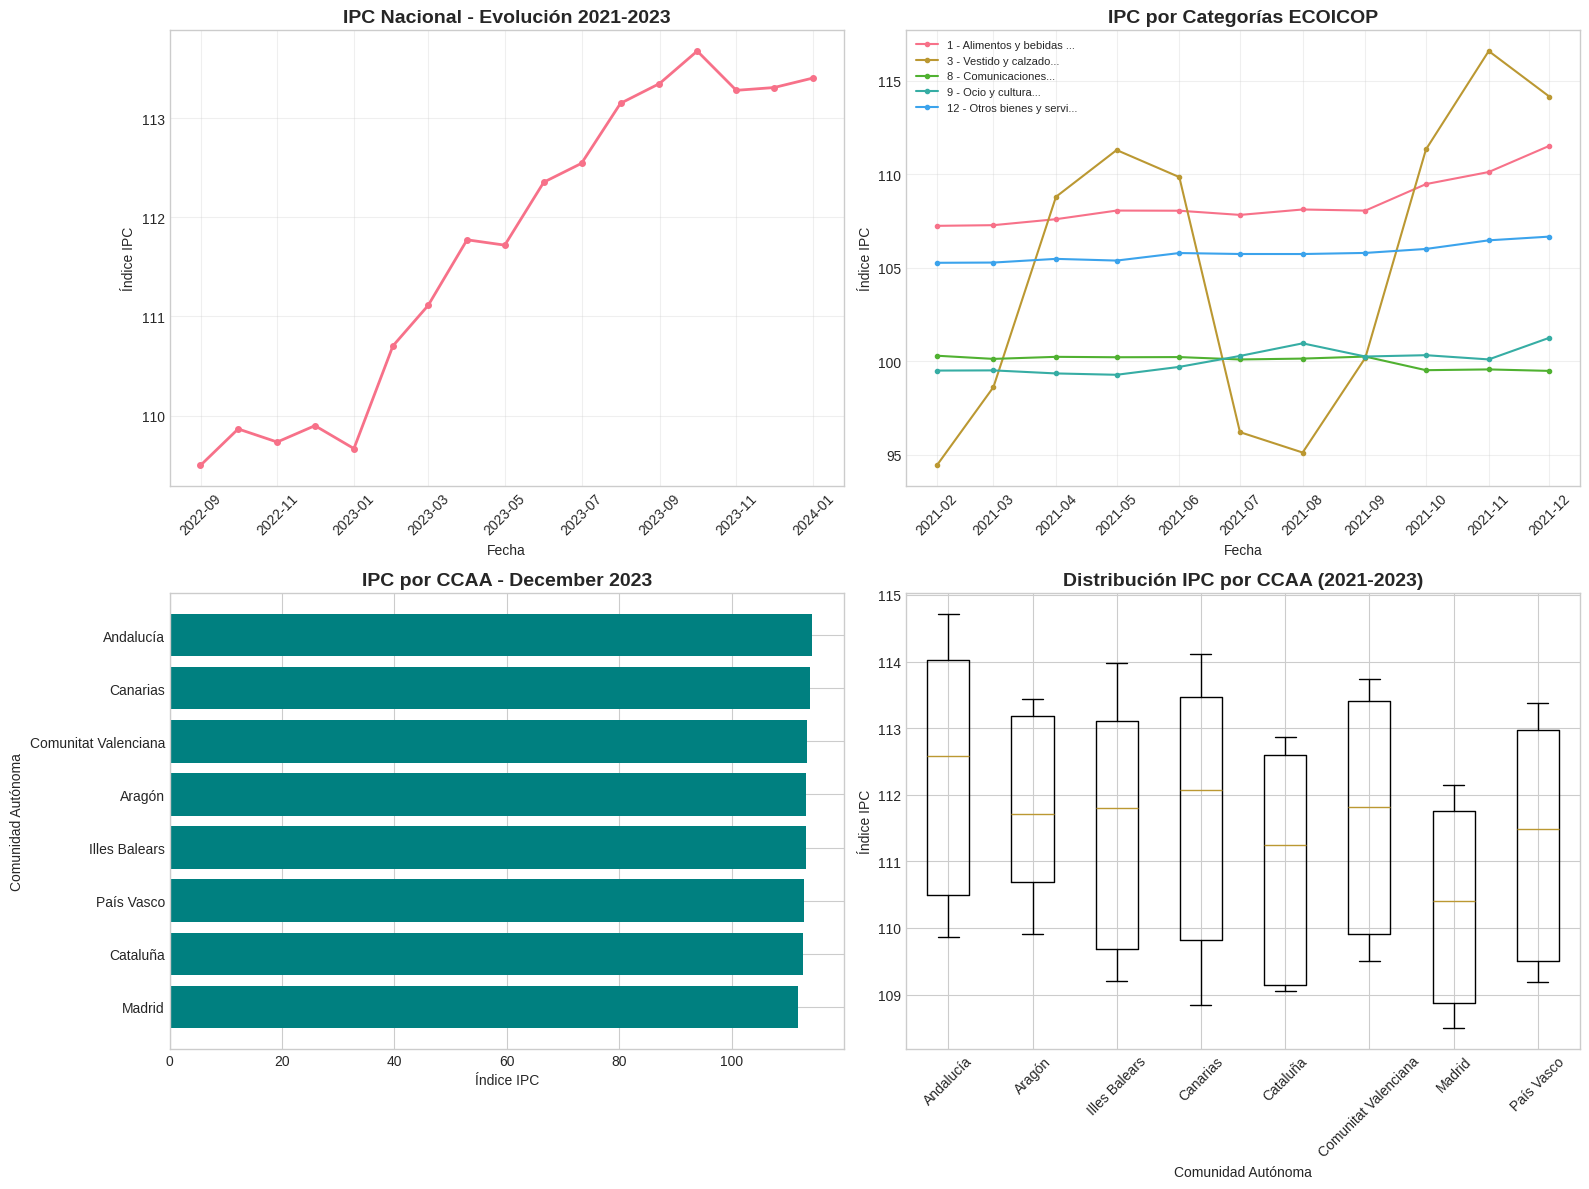


✅ Visualizaciones generadas correctamente


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. IPC Nacional - Evolución temporal
axes[0,0].plot(df_ipc_nacional['Fecha'], df_ipc_nacional['IPC_Nacional'],
               marker='o', linewidth=2, markersize=4)
axes[0,0].set_title('IPC Nacional - Evolución 2021-2023', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Fecha')
axes[0,0].set_ylabel('Índice IPC')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

# 2. IPC por Categorías - Comparación
for codigo in df_ipc_categorias['codigo_ecoicop'].unique():
    df_cat = df_ipc_categorias[df_ipc_categorias['codigo_ecoicop'] == codigo]
    nombre = df_cat['grupo_ecoicop'].iloc[0]
    axes[0,1].plot(df_cat['Fecha'], df_cat['IPC_Categoria'],
                   label=f"{codigo} - {nombre[:20]}...", marker='o', markersize=3)
axes[0,1].set_title('IPC por Categorías ECOICOP', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Fecha')
axes[0,1].set_ylabel('Índice IPC')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=45)

# 3. IPC por CCAA - Últimos valores
df_ultimo_mes = df_ipc_ccaa[df_ipc_ccaa['Fecha'] == df_ipc_ccaa['Fecha'].max()]
df_ultimo_mes = df_ultimo_mes.sort_values('IPC_CCAA', ascending=True)
axes[1,0].barh(df_ultimo_mes['ccaa'], df_ultimo_mes['IPC_CCAA'], color='teal')
axes[1,0].set_title(f"IPC por CCAA - {df_ultimo_mes['Fecha'].iloc[0].strftime('%B %Y')}",
                    fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Índice IPC')
axes[1,0].set_ylabel('Comunidad Autónoma')

# 4. Distribución IPC CCAA
axes[1,1].boxplot([df_ipc_ccaa[df_ipc_ccaa['ccaa'] == ccaa]['IPC_CCAA'].values
                    for ccaa in df_ipc_ccaa['ccaa'].unique()],
                   labels=df_ipc_ccaa['ccaa'].unique())
axes[1,1].set_title('Distribución IPC por CCAA (2021-2023)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Comunidad Autónoma')
axes[1,1].set_ylabel('Índice IPC')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones generadas correctamente")

## 📝 CELDA 9: Resumen Final

In [15]:
print("="*80)
print("📝 RESUMEN EJECUTIVO - DESCARGA OPEN DATA INE")
print("="*80)

print("\n✅ OPEN DATA DESCARGADO EXITOSAMENTE")

print("\n📊 ARCHIVOS GENERADOS:")
print("   1. ine_ipc_nacional.csv")
print("   2. ine_ipc_categorias.csv")
print("   3. ine_ipc_ccaa.csv")

print("\n📈 ESTADÍSTICAS:")
print(f"   • IPC Nacional: {len(df_ipc_nacional)} meses")
print(f"   • IPC Categorías: {len(df_ipc_categorias)} registros ({df_ipc_categorias['codigo_ecoicop'].nunique()} categorías)")
print(f"   • IPC CCAA: {len(df_ipc_ccaa)} registros ({df_ipc_ccaa['codigo_ccaa'].nunique()} comunidades)")

print("\n🎯 PRÓXIMOS PASOS:")
print("   1. ✅ Open Data descargado y validado")
print("   2. ⏳ Preparar y limpiar datasets")
print("   3. ⏳ Integrar dataset principal + Open Data")
print("   4. ⏳ Análisis comparativo (antes vs después)")
print("   5. ⏳ Visualizaciones finales")
print("   6. ⏳ Informe y conclusiones")

print("\n" + "="*80)
print("🎉 DESCARGA COMPLETADA - NOTEBOOK 02 FINALIZADO")
print("="*80)

📝 RESUMEN EJECUTIVO - DESCARGA OPEN DATA INE

✅ OPEN DATA DESCARGADO EXITOSAMENTE

📊 ARCHIVOS GENERADOS:
   1. ine_ipc_nacional.csv
   2. ine_ipc_categorias.csv
   3. ine_ipc_ccaa.csv

📈 ESTADÍSTICAS:
   • IPC Nacional: 17 meses
   • IPC Categorías: 55 registros (5 categorías)
   • IPC CCAA: 136 registros (8 comunidades)

🎯 PRÓXIMOS PASOS:
   1. ✅ Open Data descargado y validado
   2. ⏳ Preparar y limpiar datasets
   3. ⏳ Integrar dataset principal + Open Data
   4. ⏳ Análisis comparativo (antes vs después)
   5. ⏳ Visualizaciones finales
   6. ⏳ Informe y conclusiones

🎉 DESCARGA COMPLETADA - NOTEBOOK 02 FINALIZADO


---

## 📌 NOTAS IMPORTANTES:

### ✅ Lo que hemos logrado:
- Descargado IPC Nacional mensual (enero 2021 - marzo 2023)
- Descargado IPC por 5 grupos ECOICOP (categorías de productos)
- Descargado IPC por 8 Comunidades Autónomas
- Validado calidad de datos (sin nulos, períodos correctos)
- Generado visualizaciones preliminares

### 🔗 Compatibilidad con Dataset Principal:
- ✅ Mismo período temporal (2021-2023)
- ✅ Categorías mapeadas a ECOICOP
- ✅ CCAA mapeadas a ciudades españolas
- ✅ Listos para integración vía LEFT JOIN

### 🎯 Siguiente Notebook:
**`03_preparacion_datos.ipynb`**
- Limpieza final de datasets
- Aplicar mapeos geográficos y de categorías
- Preparar estructura para integración
- Validación pre-integración

---

**Autor:** Ana BM  
**Proyecto:** RETO 6 - Open Data - FUNDAE Business Analytics Nivel 4  
**GitHub:** https://github.com/AnaBMo/BA_Fundae_Nivel-4-BigData-ETL-DataMining  